IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

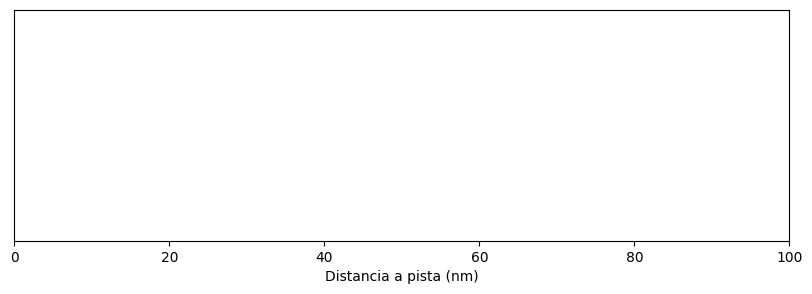

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ==============================
# Parámetros globales
# ==============================
DISTANCIA_INICIAL = 100.0  # nm
RADAR_NM = 100.0
MIN_SEP = 4.0      # minutos
BUFFER = 5.0
VEL_MARCHA_ATRAS = 200.0   # nudos
NUDO_KMH = 1.852
NM_KM = 1.852

# Velocidades permitidas por rango (nm: (v_min, v_max))
RANGOS = [
    (100, 50, 300, 250),
    (50, 15, 250, 200),
    (15, 5, 200, 150),
    (5, 0, 150, 120),
]

# ==============================
# Clase Avión
# ==============================
class Avion:
    def __init__(self, t0, id):
        self.id = id
        self.t0 = t0          # minuto en que aparece en radar
        self.distancia = DISTANCIA_INICIAL
        self.velocidad = 300  # inicial (ajustable)
        self.estado = "en_vuelo"
        self.x = DISTANCIA_INICIAL  # para graficar en pista 1D
        self.y = 0

    def actualizar(self, dt=1):
        """Avanza el avión dt minutos en su trayectoria recta hacia la pista"""
        if self.estado == "en_vuelo":
            # convertir nudos -> nm/min
            v_nm_min = self.velocidad / 60.0
            self.distancia = max(0, self.distancia - v_nm_min * dt)
            self.x = self.distancia  # usamos eje X como la pista
            if self.distancia <= 0:
                self.estado = "aterrizado"

# ==============================
# Simulación Monte Carlo
# ==============================
def simular(lambda_hora=0.2, duracion_horas=2, seed=42):
    rng = np.random.default_rng(seed)
    total_min = int(duracion_horas * 60)
    aviones = []
    activos = []

    for minuto in range(total_min):
        # Poisson arrivals (prob de nuevo avión en este minuto)
        if rng.random() < lambda_hora:
            aviones.append(Avion(t0=minuto, id=len(aviones)+1))

        # Actualizar todos los aviones en vuelo
        for avion in aviones:
            if avion.t0 <= minuto and avion.estado == "en_vuelo":
                avion.actualizar()

        # Guardar snapshot
        activos.append([(a.id, a.x) for a in aviones if a.estado == "en_vuelo"])

    return aviones, activos

# ==============================
# Visualización animada
# ==============================
def animar(aviones, activos):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.set_xlim(0, DISTANCIA_INICIAL)
    ax.set_ylim(-2, 2)
    ax.set_xlabel("Distancia a pista (nm)")
    ax.set_yticks([])

    scat = ax.scatter([], [], c="blue", s=50)

    def init():
        scat.set_offsets(np.empty((0, 2)))
        return scat,

    def update(frame):
        datos = activos[frame]
        if datos:
            xs = [d[1] for d in datos]
            ys = [0 for _ in datos]
            scat.set_offsets(np.c_[xs, ys])
        else:
            scat.set_offsets(np.empty((0, 2)))
        ax.set_title(f"Minuto {frame}")
        return scat,

    ani = animation.FuncAnimation(fig, update, frames=len(activos),
                                  init_func=init, blit=True, interval=100)
    plt.show()

# ==============================
# Ejecución
# ==============================
aviones, activos = simular(lambda_hora=0.2, duracion_horas=1)
animar(aviones, activos)
